# MovieLens 1M Recommendation System




In [4]:
from pathlib import Path
import warnings, pickle
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

DATA_DIR = Path("ml-1m")
if not DATA_DIR.exists():
    DATA_DIR = Path(".")
print("Data directory:", DATA_DIR.resolve())


Data directory: /content


## 1. Data Loading




In [5]:
ratings = pd.read_csv(DATA_DIR/"ratings.dat", sep="::", engine="python",
                         names=["UserID","MovieID","Rating","Timestamp"], encoding="latin-1")
users = pd.read_csv(DATA_DIR/"users.dat", sep="::", engine="python",
                    names=["UserID","Gender","Age","Occupation","ZipCode"], encoding="latin-1")
movies = pd.read_csv(DATA_DIR/"movies.dat", sep="::", engine="python",
                     names=["MovieID","Title","Genres"], encoding="latin-1")

print("Ratings:", ratings.shape)
print("Users:", users.shape)
print("Movies:", movies.shape)
display(ratings.head(), users.head(), movies.head())


Ratings: (514876, 4)
Users: (6040, 5)
Movies: (3883, 3)


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


,UserID,Gender,Age,Occupation,ZipCode
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


## 2. Data Inspection & EDA




In [6]:
print("Ratings info:")
ratings.info()
print("\nUsers info:")
users.info()
print("\nMovies info:")
movies.info()

print("\nRating distribution:")
display(ratings["Rating"].value_counts().sort_index())

ratings_per_user = ratings.groupby("UserID").size()
ratings_per_movie = ratings.groupby("MovieID").size()
print("Mean ratings/user:", round(ratings_per_user.mean(),2))
print("Mean ratings/movie:", round(ratings_per_movie.mean(),2))
print("Max ratings by one user:", ratings_per_user.max())
print("Max ratings for one movie:", ratings_per_movie.max())


Ratings info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514876 entries, 0 to 514875
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   UserID     514876 non-null  int64
 1   MovieID    514876 non-null  int64
 2   Rating     514876 non-null  int64
 3   Timestamp  514876 non-null  int64
dtypes: int64(4)
memory usage: 15.7 MB

Users info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   UserID      6040 non-null   int64 
 1   Gender      6040 non-null   object
 2   Age         6040 non-null   int64 
 3   Occupation  6040 non-null   int64 
 4   ZipCode     6040 non-null   object
dtypes: int64(3), object(2)
memory usage: 236.1+ KB

Movies info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dt

,count
Rating,
1,28748
2,56207
3,133905
4,180473
5,115543


Mean ratings/user: 161.91
Mean ratings/movie: 142.27
Max ratings by one user: 1850
Max ratings for one movie: 1874


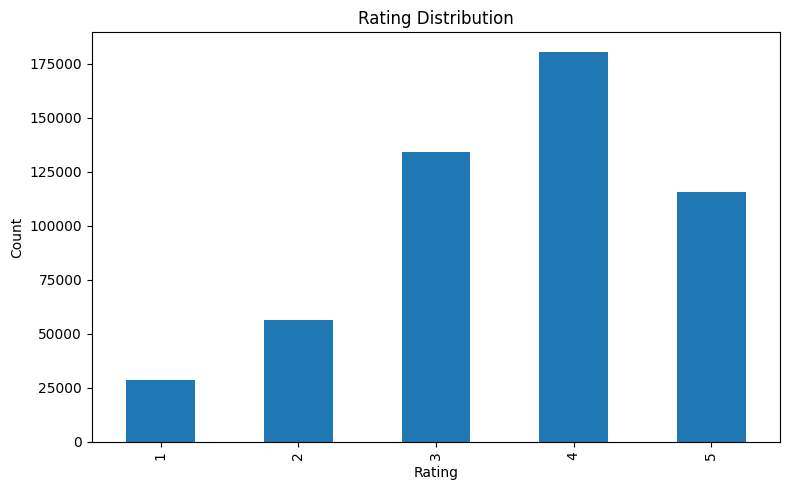

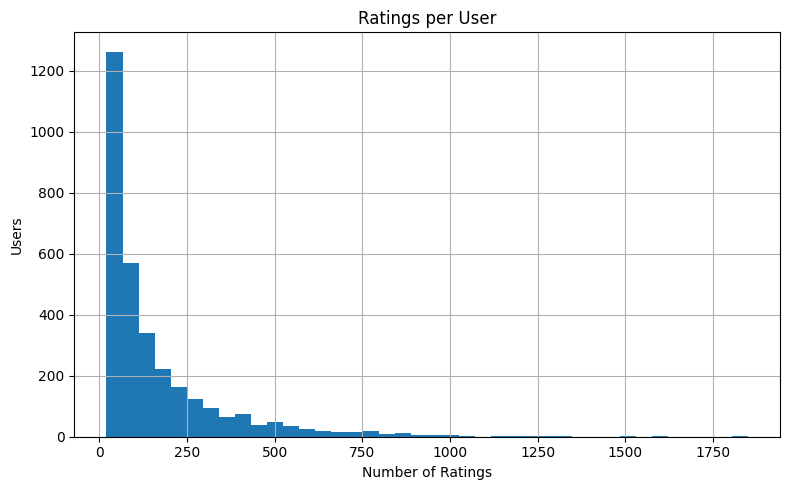

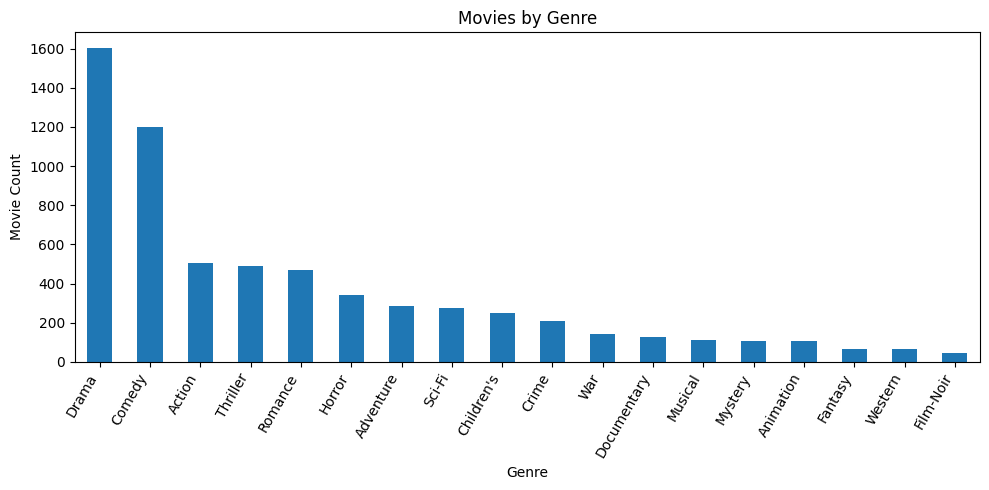

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
ratings["Rating"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Rating Distribution"); ax.set_xlabel("Rating"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ratings_per_user.hist(bins=40, ax=ax)
ax.set_title("Ratings per User"); ax.set_xlabel("Number of Ratings"); ax.set_ylabel("Users")
plt.tight_layout(); plt.show()

genre_counts = {}
for g in movies["Genres"].dropna():
    for genre in g.split("|"):
        genre_counts[genre] = genre_counts.get(genre, 0) + 1
genre_counts = pd.Series(genre_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,5))
genre_counts.plot(kind="bar", ax=ax)
ax.set_title("Movies by Genre"); ax.set_xlabel("Genre"); ax.set_ylabel("Movie Count")
plt.xticks(rotation=60, ha="right"); plt.tight_layout(); plt.show()


## 3. Data Cleaning



In [8]:
print("Missing values:")
print("ratings:", ratings.isna().sum().to_dict())
print("users:", users.isna().sum().to_dict())
print("movies:", movies.isna().sum().to_dict())

print("\nDuplicate rows:")
print("ratings:", ratings.duplicated().sum())
print("users:", users.duplicated().sum())
print("movies:", movies.duplicated().sum())

print("\nInvalid ratings:", ((ratings.Rating < 1) | (ratings.Rating > 5)).sum())
print("Unknown movie IDs:", (~ratings.MovieID.isin(movies.MovieID)).sum())
print("Unknown user IDs:", (~ratings.UserID.isin(users.UserID)).sum())

ratings = ratings.drop_duplicates()
ratings = ratings[ratings.Rating.between(1,5)]
ratings = ratings[ratings.UserID.isin(users.UserID) & ratings.MovieID.isin(movies.MovieID)].copy()
movies["Genres"] = movies["Genres"].fillna("(no genres listed)")
movies["Title"] = movies["Title"].fillna("Unknown Title")
print("Cleaned ratings:", ratings.shape)


Missing values:
ratings: {'UserID': 0, 'MovieID': 0, 'Rating': 0, 'Timestamp': 0}
users: {'UserID': 0, 'Gender': 0, 'Age': 0, 'Occupation': 0, 'ZipCode': 0}
movies: {'MovieID': 0, 'Title': 0, 'Genres': 0}

Duplicate rows:
ratings: 0
users: 0
movies: 0

Invalid ratings: 0
Unknown movie IDs: 0
Unknown user IDs: 0
Cleaned ratings: (514876, 4)


## 4. Feature Engineering



In [9]:
movies_model = movies.copy()
movies_model["content"] = movies_model["Genres"].str.replace("|"," ",regex=False).str.lower()
display(movies_model[["MovieID","Title","Genres","content"]].head())


,MovieID,Title,Genres,content
0,1,Toy Story (1995),Animation|Children's|Comedy,animation children's comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy,adventure children's fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance,comedy romance
3,4,Waiting to Exhale (1995),Comedy|Drama,comedy drama
4,5,Father of the Bride Part II (1995),Comedy,comedy


## 5. Vectorization



In [10]:
tfidf = TfidfVectorizer(token_pattern=r"(?u)\b[\w&-]+\b")
genre_matrix = tfidf.fit_transform(movies_model["content"])
print("TF-IDF shape:", genre_matrix.shape)
print("Features:", len(tfidf.get_feature_names_out()))


TF-IDF shape: (3883, 19)
Features: 19


## 6. Scaling / Normalization



In [11]:
movie_user = ratings.pivot_table(index="MovieID", columns="UserID",
                                    values="Rating", fill_value=0)
X = movie_user.to_numpy(dtype=float)
mask = X != 0
means = np.divide(X.sum(axis=1), mask.sum(axis=1),
                  out=np.zeros(X.shape[0]), where=mask.sum(axis=1)!=0)
centered = np.where(mask, X-means[:,None], 0)
sparse = csr_matrix(centered)
norms = np.sqrt(sparse.multiply(sparse).sum(axis=1)).A1
norms[norms==0] = 1
movie_normalized = sparse.multiply(1/norms[:,None]).tocsr()
print("Movie-user matrix:", movie_user.shape)


Movie-user matrix: (3619, 3180)


## 7. Model Training

### Model A: Content-Based


### Model B: Item-Based Collaborative Filtering



In [12]:
content_similarity = cosine_similarity(genre_matrix, dense_output=False)

collab_similarity = movie_normalized @ movie_normalized.T
collab_movie_ids = movie_user.index.to_numpy()
collab_id_to_idx = {int(mid): i for i,mid in enumerate(collab_movie_ids)}

movie_id_to_row = {int(mid): i for i,mid in enumerate(movies_model.MovieID)}

def content_recommend(title, n=10):
    m = movies_model[movies_model.Title.str.contains(title,case=False,regex=False,na=False)]
    if m.empty: return pd.DataFrame()
    row = m.index[0]
    scores = content_similarity[row].toarray().ravel()
    scores[row] = -1
    top = np.argsort(scores)[::-1][:n]
    out = movies_model.loc[top,["MovieID","Title","Genres"]].copy()
    out["Similarity"] = scores[top]
    return out.reset_index(drop=True)

def collaborative_recommend(title, n=10):
    m = movies_model[movies_model.Title.str.contains(title,case=False,regex=False,na=False)]
    if m.empty: return pd.DataFrame()
    mid = int(m.iloc[0].MovieID)
    if mid not in collab_id_to_idx: return pd.DataFrame()
    row = collab_id_to_idx[mid]
    scores = collab_similarity[row].toarray().ravel()
    scores[row] = -1
    top = np.argsort(scores)[::-1][:n]
    ids = collab_movie_ids[top]
    out = movies_model[movies_model.MovieID.isin(ids)][["MovieID","Title","Genres"]].copy()
    score_map = dict(zip(ids,scores[top]))
    out["Similarity"] = out.MovieID.map(score_map)
    return out.sort_values("Similarity",ascending=False).reset_index(drop=True)

display(content_recommend("Toy Story",10))
display(collaborative_recommend("Toy Story",10))


,MovieID,Title,Genres,Similarity
0,2354,"Rugrats Movie, The (1998)",Animation|Children's|Comedy,1.000000
1,2355,"Bug's Life, A (1998)",Animation|Children's|Comedy,1.000000
2,2141,"American Tail, An (1986)",Animation|Children's|Comedy,1.000000
3,2142,"American Tail: Fievel Goes West, An (1991)",Animation|Children's|Comedy,1.000000
4,3114,Toy Story 2 (1999),Animation|Children's|Comedy,1.000000
5,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Animation|Children's|Comedy,1.000000
6,3751,Chicken Run (2000),Animation|Children's|Comedy,1.000000
7,3611,Saludos Amigos (1943),Animation|Children's|Comedy,1.000000
8,1064,Aladdin and the King of Thieves (1996),Animation|Children's|Comedy,1.000000
9,2090,"Rescuers, The (1977)",Animation|Children's,0.955078


,MovieID,Title,Genres,Similarity
0,3114,Toy Story 2 (1999),Animation|Children's|Comedy,0.396715
1,2355,"Bug's Life, A (1998)",Animation|Children's|Comedy,0.302068
2,588,Aladdin (1992),Animation|Children's|Comedy|Musical,0.290865
3,595,Beauty and the Beast (1991),Animation|Children's|Musical,0.231853
4,364,"Lion King, The (1994)",Animation|Children's|Musical,0.223684
5,34,Babe (1995),Children's|Comedy|Drama,0.206783
6,1270,Back to the Future (1985),Comedy|Sci-Fi,0.187537
7,2080,Lady and the Tramp (1955),Animation|Children's|Comedy|Musical|Romance,0.178215
8,1029,Dumbo (1941),Animation|Children's|Musical,0.173980
9,2054,"Honey, I Shrunk the Kids (1989)",Adventure|Children's|Comedy|Fantasy|Sci-Fi,0.173040


## Popularity Baseline



In [13]:
def popularity_recommend(n=10, df=ratings):
    stats = df.groupby("MovieID").agg(Count=("Rating","size"),MeanRating=("Rating","mean")).reset_index()
    global_mean = df.Rating.mean()
    m = stats.Count.quantile(.75)
    stats["Score"] = (stats.Count/(stats.Count+m))*stats.MeanRating + (m/(stats.Count+m))*global_mean
    return stats.sort_values(["Score","Count"],ascending=False).head(n).merge(
        movies_model[["MovieID","Title","Genres"]],on="MovieID")

display(popularity_recommend())


,MovieID,Count,MeanRating,Score,Title,Genres
0,318,1151,4.540400,4.409691,"Shawshank Redemption, The (1994)",Drama
1,527,1236,4.522654,4.402053,Schindler's List (1993),Drama|War
2,1198,1265,4.505138,4.389148,Raiders of the Lost Ark (1981),Action|Adventure
3,858,1108,4.505415,4.375259,"Godfather, The (1972)",Action|Crime|Drama
4,260,1539,4.445744,4.354482,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi
5,50,903,4.507198,4.352130,"Usual Suspects, The (1995)",Crime|Thriller
6,2762,1196,4.404682,4.296085,"Sixth Sense, The (1999)",Thriller
7,750,697,4.441894,4.263905,Dr. Strangelove or: How I Learned to Stop Worr...,Sci-Fi|War
8,593,1334,4.351574,4.259214,"Silence of the Lambs, The (1991)",Drama|Thriller
9,1148,453,4.520971,4.251906,"Wrong Trousers, The (1993)",Animation|Comedy


## 8. Validation & Testing



In [14]:
rng = np.random.RandomState(42)
train_parts, test_pairs = [], []

for uid, group in ratings.groupby("UserID"):
    if len(group) >= 5:
        row = group.sample(1, random_state=int(rng.randint(1_000_000))).iloc[0]
        test_pairs.append((int(uid), int(row.MovieID)))
        train_parts.append(group.drop(index=row.name))
    else:
        train_parts.append(group)

eval_train = pd.concat(train_parts, ignore_index=True)

stats = eval_train.groupby("MovieID").agg(Count=("Rating","size"),Mean=("Rating","mean"))
global_mean = eval_train.Rating.mean()
m = stats.Count.quantile(.75)
stats["Score"] = (stats.Count/(stats.Count+m))*stats.Mean + (m/(stats.Count+m))*global_mean
popular_ids = stats.sort_values("Score",ascending=False).index.tolist()

hits = 0
precision_sum = 0
for uid, actual in test_pairs:
    seen = set(eval_train.loc[eval_train.UserID==uid,"MovieID"])
    recs = [x for x in popular_ids if x not in seen][:10]
    hit = int(actual in recs)
    hits += hit
    precision_sum += hit/10

precision_at_10 = precision_sum/len(test_pairs)
recall_at_10 = hits/len(test_pairs)
print("Evaluation users:",len(test_pairs))
print("Popularity Precision@10:",round(precision_at_10,4))
print("Popularity Recall@10:",round(recall_at_10,4))
print("Popularity Hit Rate@10:",round(recall_at_10,4))


Evaluation users: 3180
Popularity Precision@10: 0.0052
Popularity Recall@10: 0.0519
Popularity Hit Rate@10: 0.0519


## 9. Experimentation & Comparison

Three approaches are compared conceptually and through appropriate metrics:

1. Popularity — rating count + average rating.
2. Content-based — genre similarity.
3. Item-based collaborative filtering — user rating behavior.



In [15]:
content_scores = []
for i in range(min(1000, genre_matrix.shape[0])):
    s = content_similarity[i].toarray().ravel()
    s[i] = -1
    top = np.argsort(s)[::-1][:10]
    content_scores.append(s[top].mean())

comparison = pd.DataFrame({
    "Approach":["Popularity","Content-Based","Item-Based Collaborative"],
    "Signal":["Popularity/rating statistics","Genres","User rating behavior"],
    "Evaluation":["Precision@10 / Recall@10 / HitRate@10",
                  f"Mean top-10 cosine similarity = {np.mean(content_scores):.4f}",
                  "Similarity-based recommendations; inspect examples"]
})
display(comparison)


,Approach,Signal,Evaluation
0,Popularity,Popularity/rating statistics,Precision@10 / Recall@10 / HitRate@10
1,Content-Based,Genres,Mean top-10 cosine similarity = 0.9880
2,Item-Based Collaborative,User rating behavior,Similarity-based recommendations; inspect exam...


## 10. Model Saving

The final artifact is saved as `movie_recommender.pkl`. This project intentionally does not include the `.pkl` file in the deliverables. Run this cell after training to create it.


In [18]:
artifact = {
    "movies": movies_model[["MovieID","Title","Genres"]].copy(),
    "tfidf": tfidf,
    "genre_matrix": genre_matrix,
    "content_similarity": content_similarity,
    "collab_similarity": collab_similarity,
    "collab_movie_ids": collab_movie_ids,
    "collab_id_to_idx": collab_id_to_idx,
    "popularity": popularity_recommend(50),
    "model_version": "MovieLens1M-v1"
}

with open("movie_recommender.pkl","wb") as f:
    pickle.dump(artifact,f,protocol=pickle.HIGHEST_PROTOCOL)

print("Created movie_recommender.pkl")


Created movie_recommender.pkl


In [20]:
from google.colab import files

files.download("movie_recommender.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>